In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# ============================================================
# OLIST E-COMMERCE ANALYSIS — COMPLETE VISUALIZATION NOTEBOOK
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

BASE = '/kaggle/input/datasets/rebeltalk/olist-analytics-exports/'

# ── Load all data ──
print("Loading data...")
order_master     = pd.read_csv(BASE + 'order_master.csv',
                    parse_dates=['order_purchase_time'])
product_master   = pd.read_csv(BASE + 'product_master.csv')
customer_summary = pd.read_csv(BASE + 'customer_summary.csv',
                    parse_dates=['first_order','last_order'])
seller_summary   = pd.read_csv(BASE + 'seller_summary.csv')
delivery_metrics = pd.read_csv(BASE + 'delivery_metrics.csv')
rfm              = pd.read_csv(BASE + 'rfm_segments.csv')
cohort      = pd.read_csv(BASE + 'cohort.csv')
monthly         = pd.read_csv(BASE + 'monthly_revenue.csv',
                    parse_dates=['month'])
payment=pd.read_csv('/kaggle/input/datasets/rebeltalk/payment-raw/order_payment_clean.csv')
delivered = order_master[order_master['order_status'] == 'delivered'].copy()
print("✅ All data loaded")
print(f"   Orders: {len(order_master):,}")
print(f"   Customers: {customer_summary.shape[0]:,}")
print(f"   Sellers: {seller_summary.shape[0]:,}")


/kaggle/input/datasets/rebeltalk/payment-raw/order_payment_clean.csv
/kaggle/input/datasets/rebeltalk/olist-analytics-exports/order_master.csv
/kaggle/input/datasets/rebeltalk/olist-analytics-exports/customer_summary.csv
/kaggle/input/datasets/rebeltalk/olist-analytics-exports/rfm_segments.csv
/kaggle/input/datasets/rebeltalk/olist-analytics-exports/monthly_revenue.csv
/kaggle/input/datasets/rebeltalk/olist-analytics-exports/cohort.csv
/kaggle/input/datasets/rebeltalk/olist-analytics-exports/seller_summary.csv
/kaggle/input/datasets/rebeltalk/olist-analytics-exports/delivery_metrics.csv
/kaggle/input/datasets/rebeltalk/olist-analytics-exports/product_master.csv
Loading data...
✅ All data loaded
   Orders: 99,441
   Customers: 93,471
   Sellers: 3,095


In [2]:
total_revenue=delivered['total_payment'].sum()
total_orders=delivered['order_id'].nunique()
total_customers=order_master['customer_unique_id'].nunique()
avg_order_value=total_revenue/total_orders
avg_review=order_master['review_score'].mean()
late_pct=delivery_metrics['late_delivery'].mean()*100
repeat_rate=(customer_summary['total_orders']>1).mean()*100

print("----BUSINESS KPI----")
print(f"Total Revenue   :${total_revenue:,.2f}")
print(f"Total Orders    :{total_orders:,}")
print(f"Avg Order Value :${avg_order_value:.2f}")
print(f"Avg Review Score   : {avg_review:.2f} / 5.0")
print(f"Late Delivery %    : {late_pct:.1f}%")
print(f"Repeat Customer %  : {repeat_rate:.1f}%")

----BUSINESS KPI----
Total Revenue   :$15,422,461.77
Total Orders    :96,478
Avg Order Value :$159.85
Avg Review Score   : 4.09 / 5.0
Late Delivery %    : 8.1%
Repeat Customer %  : 2.9%


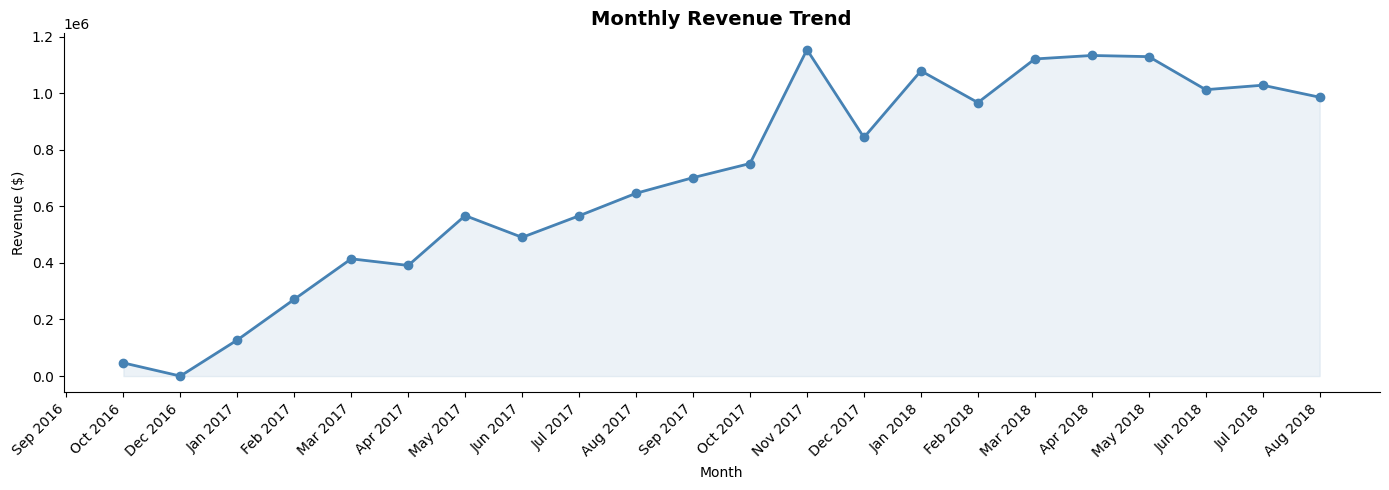

In [3]:
monthly = pd.read_csv('/kaggle/input/datasets/rebeltalk/olist-analytics-exports/monthly_revenue.csv', 
                       parse_dates=['month'])

monthly = monthly.sort_values('month')
monthly['month_label'] = monthly['month'].dt.strftime('%b %Y')

plt.figure(figsize=(14, 5))
plt.plot(monthly['month_label'], monthly['revenue'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly)), monthly['revenue'],
                 alpha=0.1, color='steelblue')
plt.xticks(range(len(monthly)), monthly['month_label'],
           rotation=45, ha='right')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

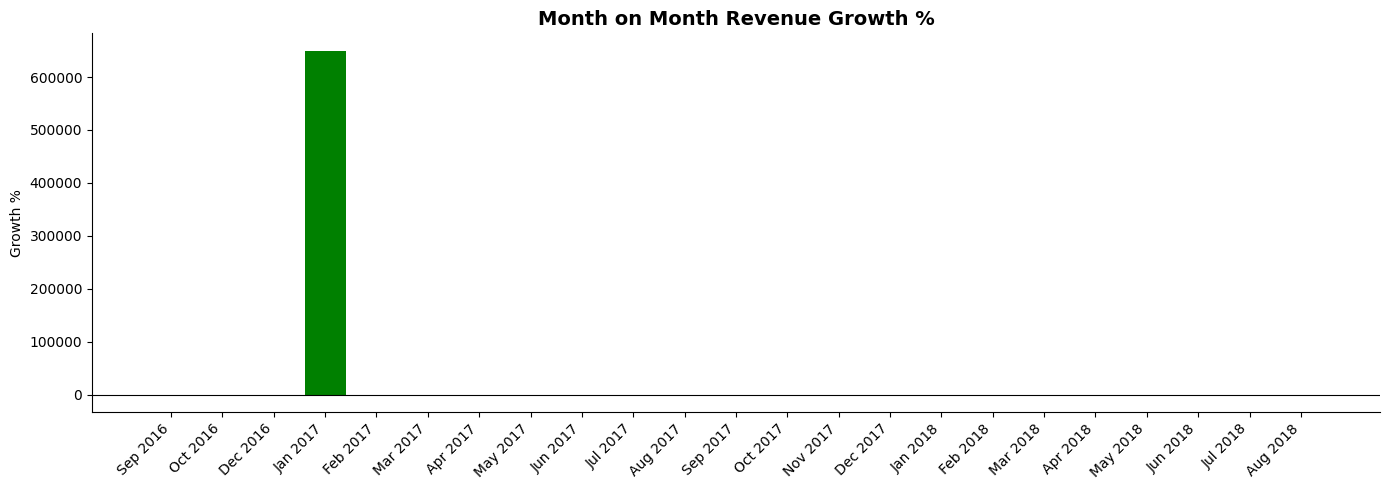

In [4]:
#MONTH ON MONTH GROWTH RATE
monthly['prev_revenue']=monthly['revenue'].shift(1)
monthly['mom_growth']=((monthly['revenue']-
                        monthly['prev_revenue'])/
                      monthly['prev_revenue']*100)

plt.figure(figsize=(14,5))
colors=['green' if x>=0 else 'red'
       for x in monthly['mom_growth'].fillna(0)]
plt.bar(monthly['month_label'],
       monthly['mom_growth'].fillna(0),
       color=colors)
plt.axhline(0,color='black',linewidth=0.8)
plt.xticks(rotation=45,ha='right')
plt.title('Month on Month Revenue Growth %',
         fontsize=14,fontweight='bold')
plt.ylabel('Growth %')
plt.tight_layout()
plt.savefig('mom_growth_png')
plt.show()


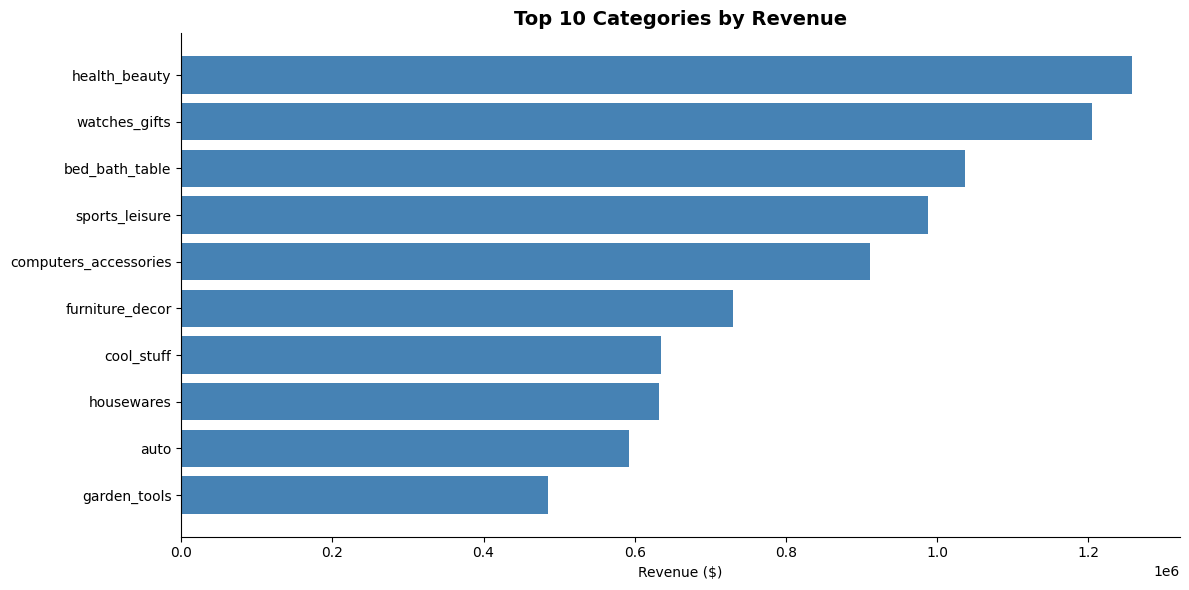

In [5]:
#REVENUE BY CATEGORY
cat_rev=(product_master.groupby('product_category_name_english')
        ['price'].sum()
        .nlargest(10)
        .sort_values()
        .reset_index())
cat_rev.columns=['category','revenue']
plt.figure(figsize=(12,6))
plt.barh(cat_rev['category'],cat_rev['revenue'],
        color='steelblue')
plt.title('Top 10 Categories by Revenue',
         fontsize=14, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig('category_revenue.png')
plt.show()

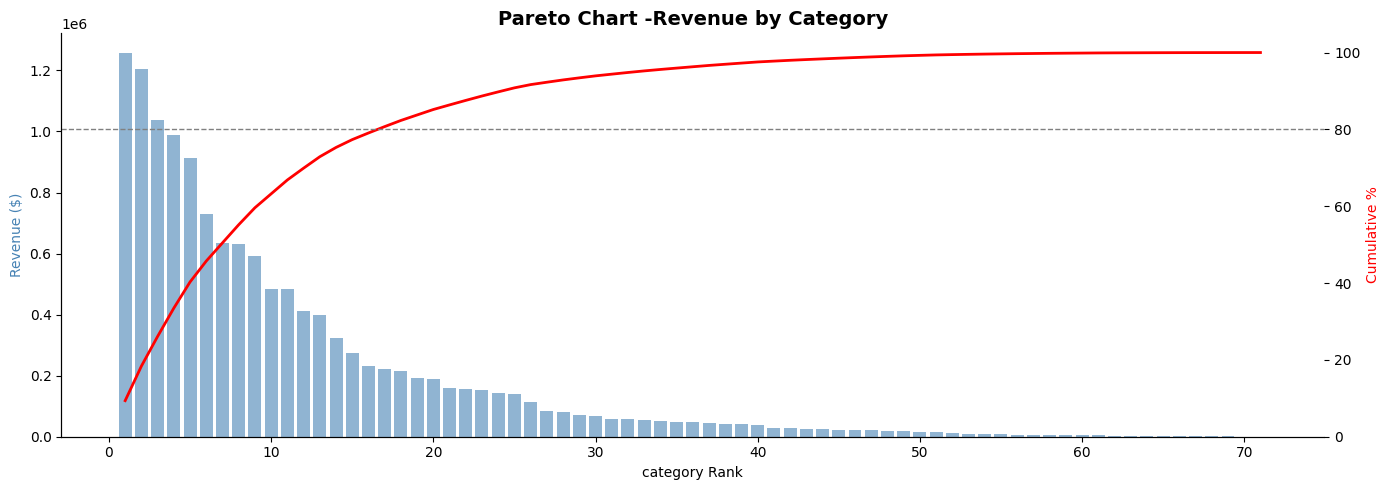

In [6]:
#CUMMULATIVE REVENUE
cat_all=(product_master.groupby('product_category_name_english')
        ['price'].sum()
        .sort_values(ascending=False)
        .reset_index())
cat_all.columns=['category','revenue']
cat_all['cumulative_pct']=cat_all['revenue'].cumsum()/cat_all['revenue'].sum()*100
cat_all['rank']=range(1,len(cat_all)+1)

fig,ax1=plt.subplots(figsize=(14,5))
ax2=ax1.twinx()
ax1.bar(cat_all['rank'],cat_all['revenue'],
        color='steelblue',alpha=0.6)
ax2.plot(cat_all['rank'],cat_all['cumulative_pct'],
        color='red',linewidth=2)
ax2.axhline(80,color='grey',linestyle='--',linewidth=1)
ax1.set_xlabel('category Rank')
ax1.set_ylabel('Revenue ($)',color='steelblue')
ax2.set_ylabel('Cumulative %',color='red')
ax2.set_ylim(0,105)
plt.title('Pareto Chart -Revenue by Category',fontsize=14,
         fontweight='bold')
plt.tight_layout()
plt.savefig('pareto.png')
plt.show()


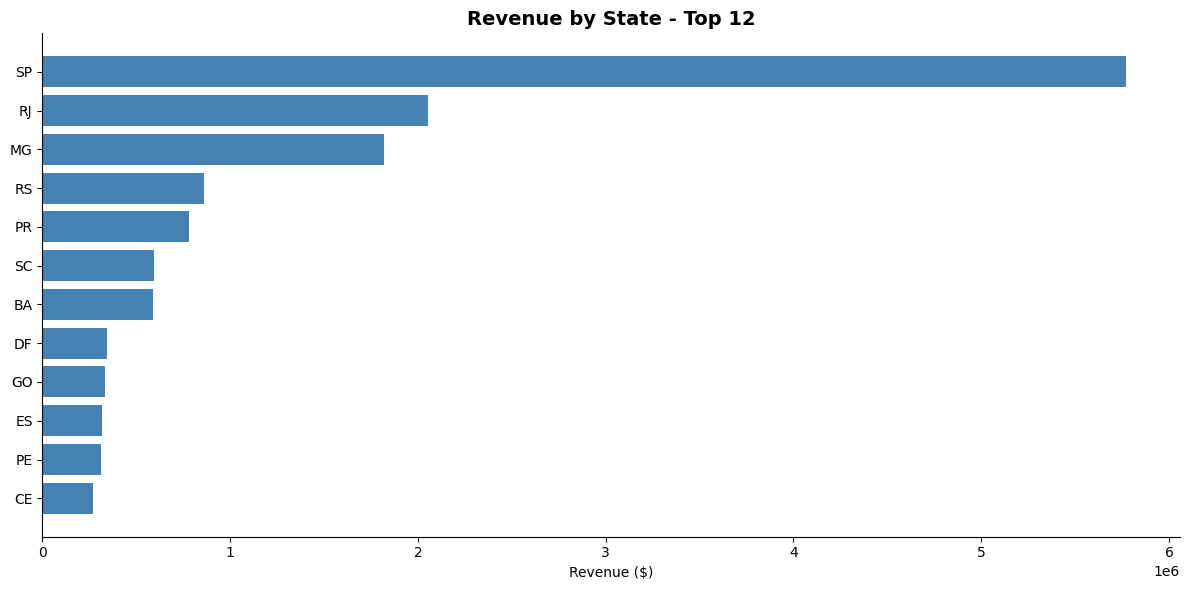

In [7]:
#REVENUE BY STATE
state_rev=(delivered.groupby('customer_state')['total_payment']
          .sum()
          .nlargest(12)
          .sort_values()
          .reset_index())
state_rev.columns=['state','revenue']
plt.figure(figsize=(12,6))
plt.barh(state_rev['state'],state_rev['revenue'],
        color='steelblue')
plt.title('Revenue by State - Top 12',fontsize=14,fontweight='bold')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig('state_revenue.png')
plt.show()

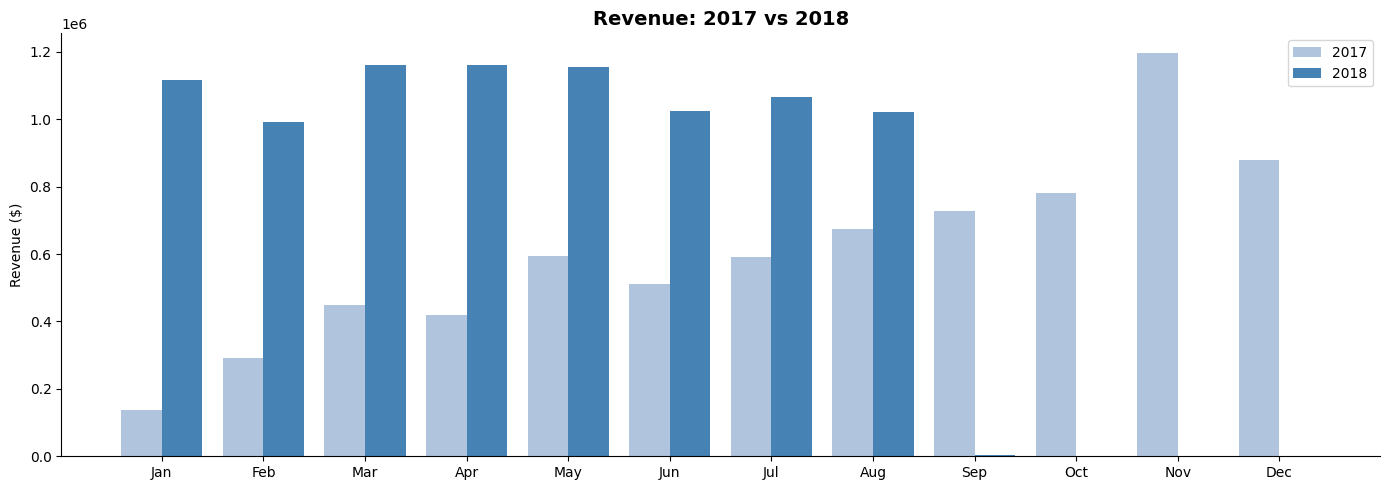

In [8]:
#Year on Year Revenue 
order_master['year']=order_master['order_purchase_time'].dt.year
order_master['month']=order_master['order_purchase_time'].dt.month
yoy=order_master.groupby(['year','month'])['total_payment'].sum().reset_index()
y2017=yoy[yoy['year']==2017].set_index('month')['total_payment']
y2018=yoy[yoy['year']==2018].set_index('month')['total_payment']

months=['Jan','Feb','Mar','Apr','May','Jun',
       'Jul','Aug','Sep','Oct','Nov','Dec']
x=range(1,13)

plt.figure(figsize=(14,5))
plt.bar([i - 0.2 for i in x],
        [y2017.get(m,0) for m in x],
       width=0.4, label='2017',color='lightsteelblue')
plt.bar([i+0.2 for i in x],
       [y2018.get(m,0) for m in x],
       width=0.4, label='2018',color='steelblue')
plt.xticks(list(x), months)
plt.title('Revenue: 2017 vs 2018',fontsize=14,fontweight='bold')
plt.ylabel('Revenue ($)')
plt.legend()
plt.tight_layout()
plt.savefig('yoy_revenue.png')
plt.show()

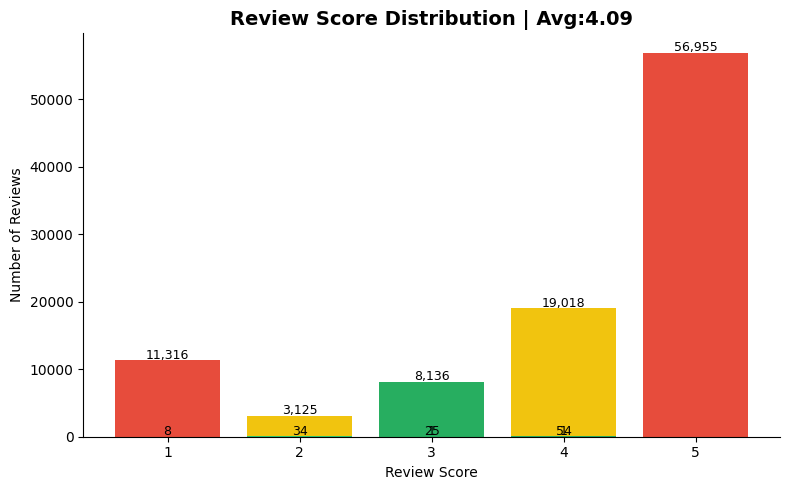

In [9]:
#REVIEW SCORE DISTRIBUTION
review_counts=(order_master['review_score']
              .dropna()
              .value_counts()
              .sort_index())
plt.figure(figsize=(8,5))
bars=plt.bar(review_counts.index.astype(int),
            review_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
for bar, val in zip(bars, review_counts.values):
    plt.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+200,
            f'{val:,}',ha='center',fontsize=9)
plt.title(f'Review Score Distribution | Avg:{
order_master['review_score'].mean():.2f}',
         fontsize=14,fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks([1,2,3,4,5])
plt.tight_layout()
plt.savefig('review_distribution.png')
plt.show()
    


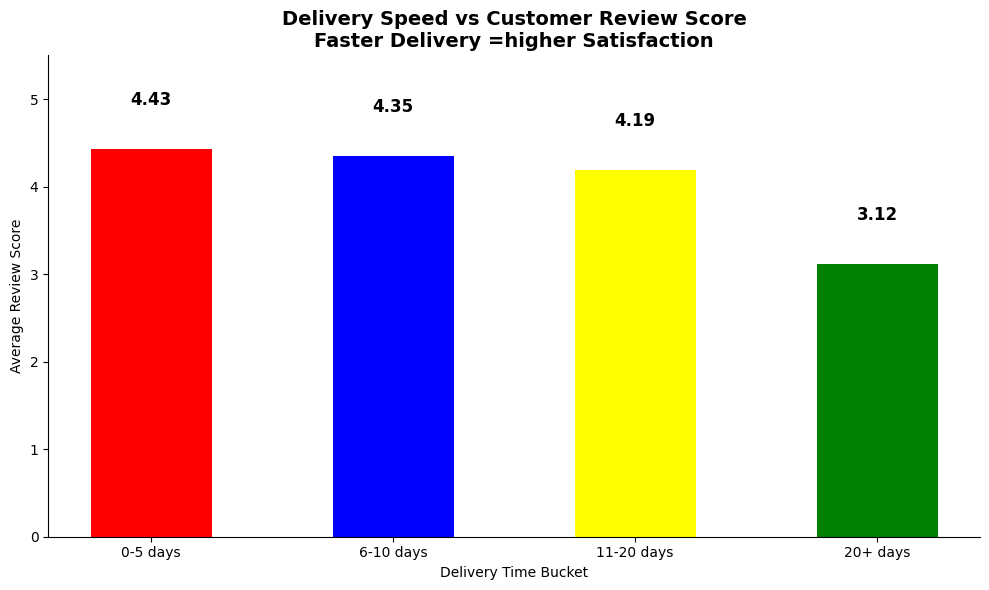


Key Insight:Review drops from4.43 to 3.12when delivery takes 20+ days


In [10]:
#DELIVERY SPEED VS REVIEW SCORE

#MERGE DELIVERY WITH REVIEW SCORES
dm=delivery_metrics.merge(
    order_master[['order_id','review_score']].dropna(),
    on='order_id'
)

#CREATING DELIVERY BUCKETS
dm['bucket']=pd.cut(
    dm['delivery_days'],
    bins=[0,5,10,20,200],
    labels=['0-5 days','6-10 days','11-20 days','20+ days']
)

#AVG REVIEW PER BUCKET
bucket_avg=dm.groupby('bucket')['review_score'].mean()

plt.figure(figsize=(10,6))
bars=plt.bar(bucket_avg.index,
            bucket_avg.values,
            color=['red','blue','yellow','green'],
             width=0.5
            )
for bar, val in zip(bars,bucket_avg.values):
    plt.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.5,
            f'{val:.2f}',ha='center',
            fontsize=12,fontweight='bold')
plt.ylim(0,5.5)
plt.title('Delivery Speed vs Customer Review Score\n'
         'Faster Delivery =higher Satisfaction',
          fontsize=14,fontweight='bold'
         )
plt.xlabel('Delivery Time Bucket')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.savefig('delivery_vs_review.png')
plt.show()

print(f"\nKey Insight:Review drops from"
     f"{bucket_avg.iloc[0]:.2f} to {bucket_avg.iloc[-1]:.2f}"
f"when delivery takes 20+ days")

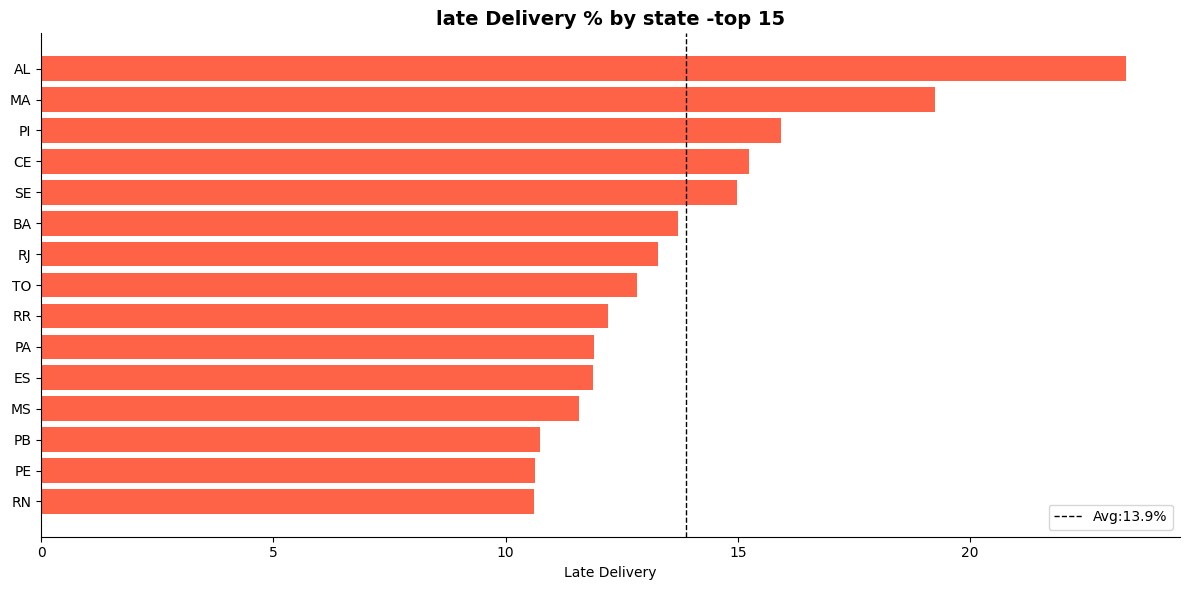

In [11]:
#LATE DELIVERY BY STATE
dm_state=dm.merge(
    order_master[['order_id','customer_state']],on='order_id'
)
late_state=(dm_state.groupby('customer_state')['late_delivery']
            .mean()*100
           .reset_index() if False else
            dm_state.groupby('customer_state')['late_delivery']
            .mean()
            .mul(100)
            .nlargest(15)
            .sort_values()
            .reset_index())
late_state.columns=['state','late_pct']
plt.figure(figsize=(12,6))
plt.barh(late_state['state'],late_state['late_pct'],
        color='tomato')
plt.axvline(late_state['late_pct'].mean(),
           color='black',linestyle='--',linewidth=1,
           label=f'Avg:{late_state['late_pct'].mean():.1f}%')
plt.title('late Delivery % by state -top 15',
         fontsize=14, fontweight='bold')
plt.xlabel('Late Delivery')
plt.legend()
plt.tight_layout()
plt.savefig('late_delivery_state.png')
plt.show()

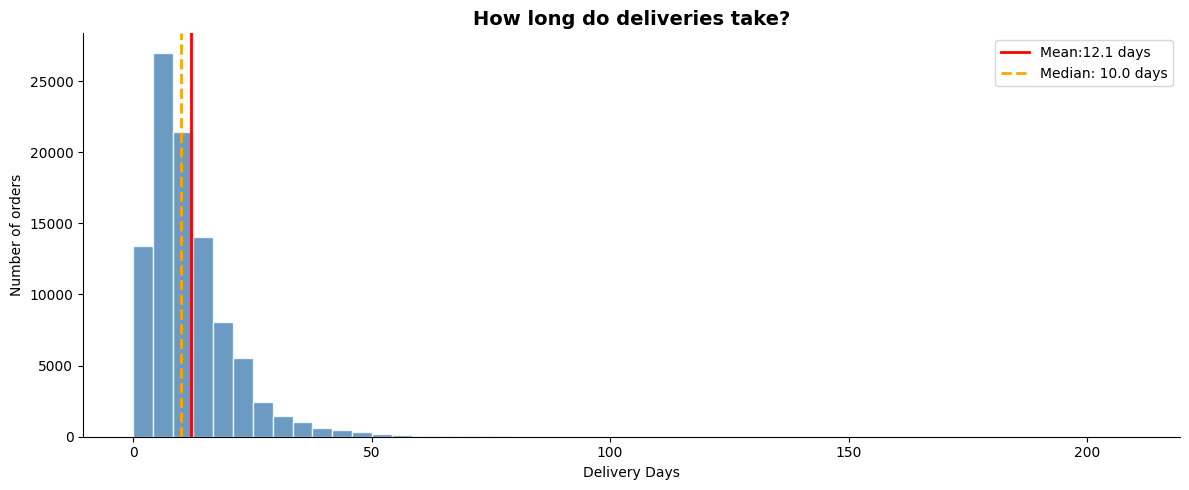

In [12]:
#DELIVERY DAYS DISTRIBUTION
plt.figure(figsize=(12,5))
plt.hist(delivery_metrics['delivery_days'].dropna(),
        bins=50,color='steelblue',
        edgecolor='white',alpha=0.8)
plt.axvline(delivery_metrics['delivery_days'].mean(),
           color='red',linewidth='2',
           label=f'Mean:{delivery_metrics['delivery_days']
           .mean():.1f} days')
plt.axvline(delivery_metrics['delivery_days'].median(),
           color='orange',linewidth=2,linestyle='--',
            label=f'Median: {delivery_metrics['delivery_days']
            .median():.1f} days')
plt.title('How long do deliveries take?',
         fontsize=14,fontweight='bold')
plt.xlabel('Delivery Days')
plt.ylabel('Number of orders')
plt.legend()
plt.tight_layout()
plt.savefig('delivery_distribution.png')
plt.show()

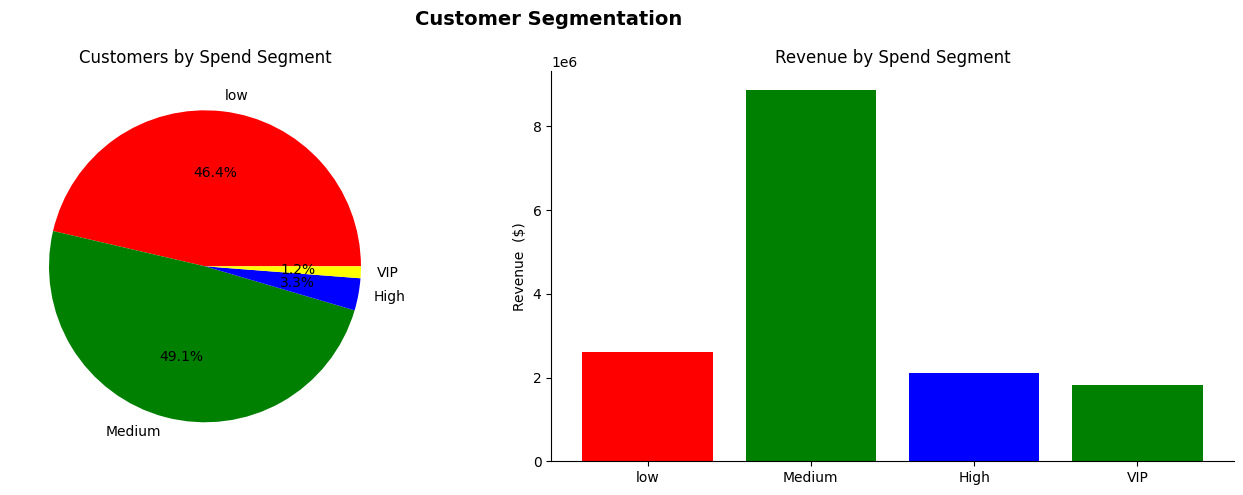

In [13]:
#CUSTOMER SPEND SEGMENTS
customer_summary['segment']=pd.cut(
    customer_summary['tot_spent'],
    bins=[0,100,500,1000,float('inf')],
    labels=['low','Medium','High','VIP']
)
seg=customer_summary.groupby('segment').agg(
    count=('customer_unique_id','count'),
    revenue=('tot_spent','sum')
).reset_index()

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
ax1.pie(seg['count'],labels=seg['segment'],
       autopct='%1.1f%%',
       colors=['red','green','blue','yellow'])
ax1.set_title('Customers by Spend Segment')

ax2.bar(seg['segment'],seg['revenue'],
       color=['red','green','blue','green'])
ax2.set_title('Revenue by Spend Segment')
ax2.set_ylabel('Revenue  ($)')
plt.suptitle('Customer Segmentation',
            fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('customer_segments_png')
plt.show()

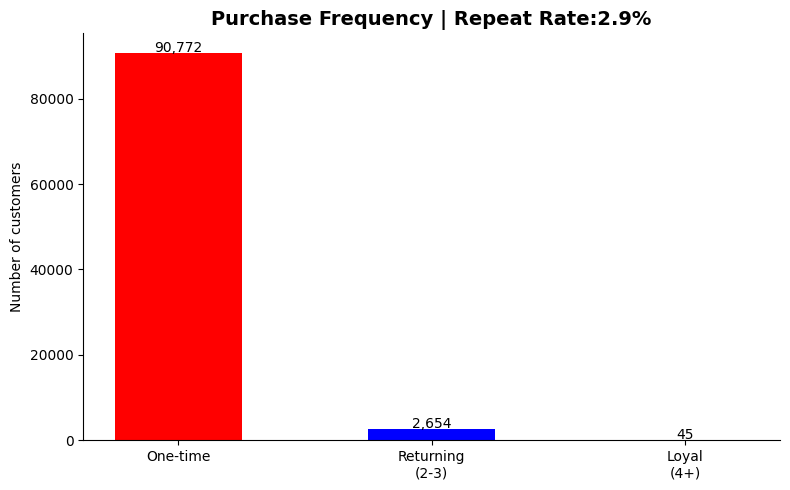

In [14]:
#REPEAT VS ONE TIME BUYERS
one_time=(customer_summary['total_orders']==1).sum()
returning=((customer_summary['total_orders']>=2) &
          (customer_summary['total_orders']<=3)).sum()
loyal=(customer_summary['total_orders']>=4).sum()
labels=['One-time','Returning\n(2-3)','Loyal\n(4+)']
values=[one_time, returning,loyal]

plt.figure(figsize=(8,5))
bars=plt.bar(labels,values,
            color=['red','blue','green','yellow'],
            width=0.5)
for bar, val in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+100,
            f'{val:,}',ha='center',fontsize=10)
plt.title(f'Purchase Frequency | Repeat Rate:'
         f'{(customer_summary['total_orders']>1).mean()*100:.1f}%',
fontsize=14, fontweight='bold')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.savefig('repeat_customers.png')
plt.show()
    

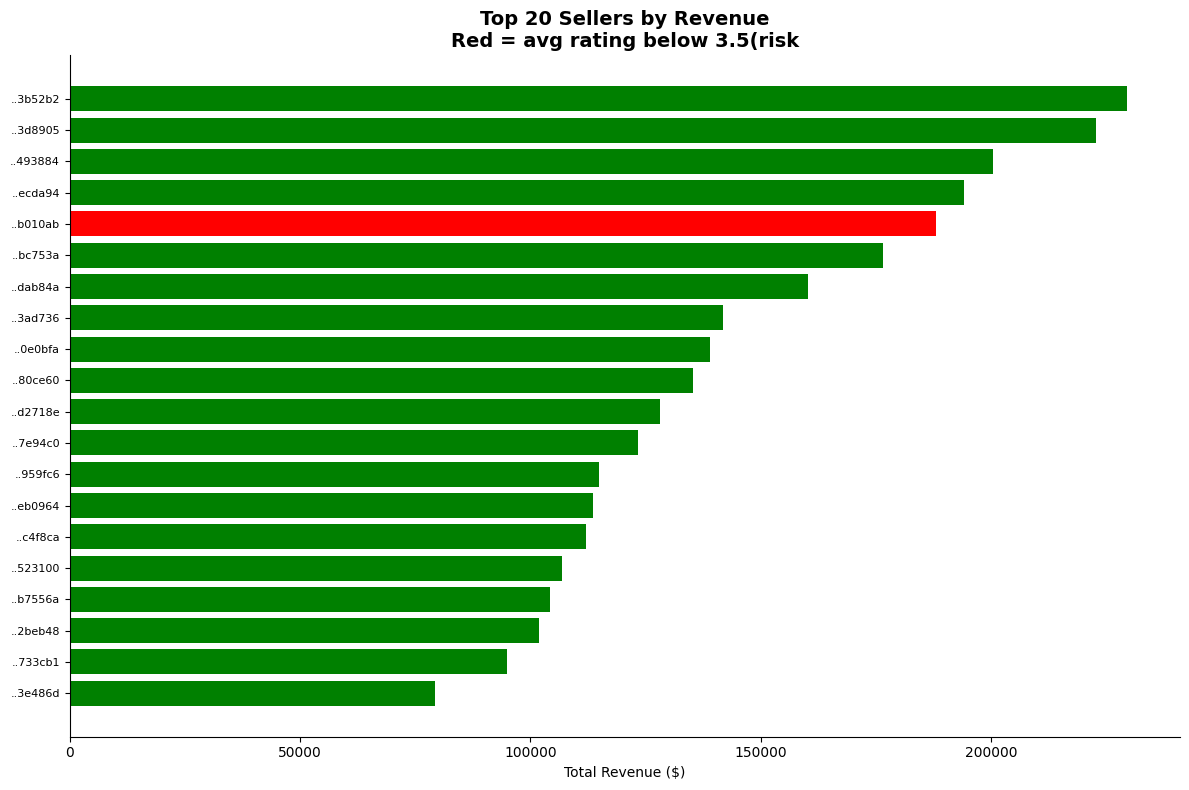

In [15]:
#TOP 2O SELLERS
top_sellers=(seller_summary.nlargest(20,'total_revenue')
            .sort_values('total_revenue'))
colors=['red' if r<3.5 else 'green'
       for r in top_sellers['avg_rating']]
plt.figure(figsize=(12,8))
plt.barh(range(len(top_sellers)),
        top_sellers['total_revenue'],
        color=colors)
plt.yticks(range(len(top_sellers)),
          [f"..{s[-6:]}" for s in top_sellers['seller_id']],
          fontsize=8)
plt.title('Top 20 Sellers by Revenue\n'
         'Red = avg rating below 3.5(risk',
         fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('top_sellers.png')
plt.show()


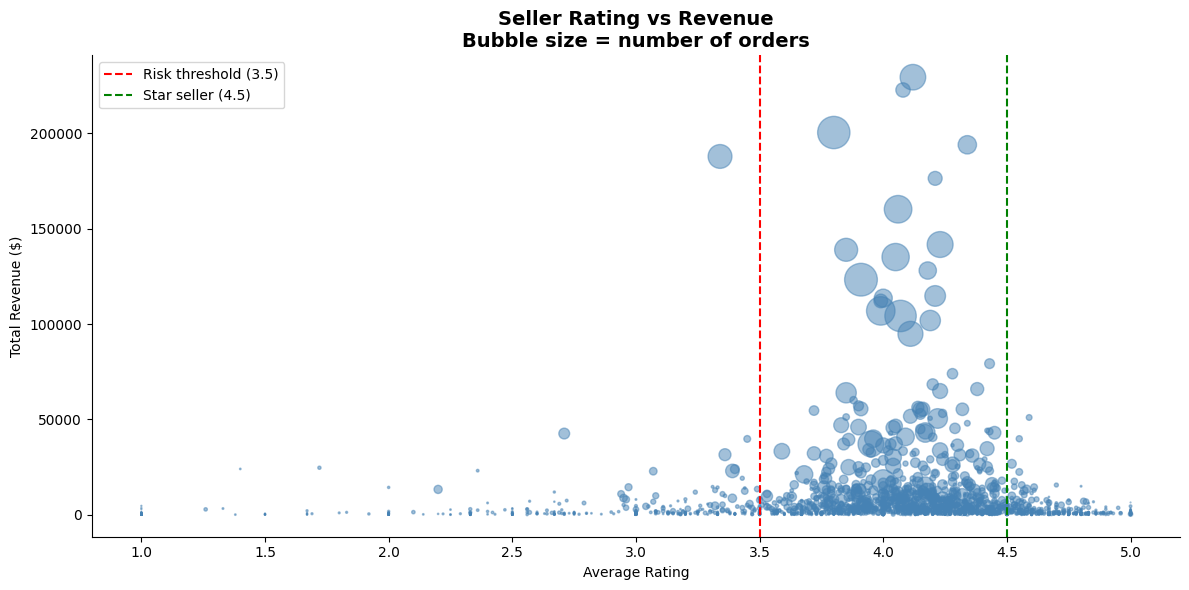

In [16]:
#SELLER RATING VS REVENUE
plt.figure(figsize=(12,6))
plt.scatter(seller_summary['avg_rating'],
           seller_summary['total_revenue'],
           alpha=0.5,color='steelblue',
           s=seller_summary['total_orders']*0.3)
plt.axvline(3.5,color='red',linestyle='--',
           linewidth=1.5,label='Risk threshold (3.5)')
plt.axvline(4.5,color='green',linestyle='--',
           linewidth=1.5,label='Star seller (4.5)')
plt.title('Seller Rating vs Revenue\n'
         'Bubble size = number of orders',
         fontsize=14,fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Total Revenue ($)')
plt.legend()
plt.tight_layout()
plt.savefig('seller_risk.png')
plt.show()

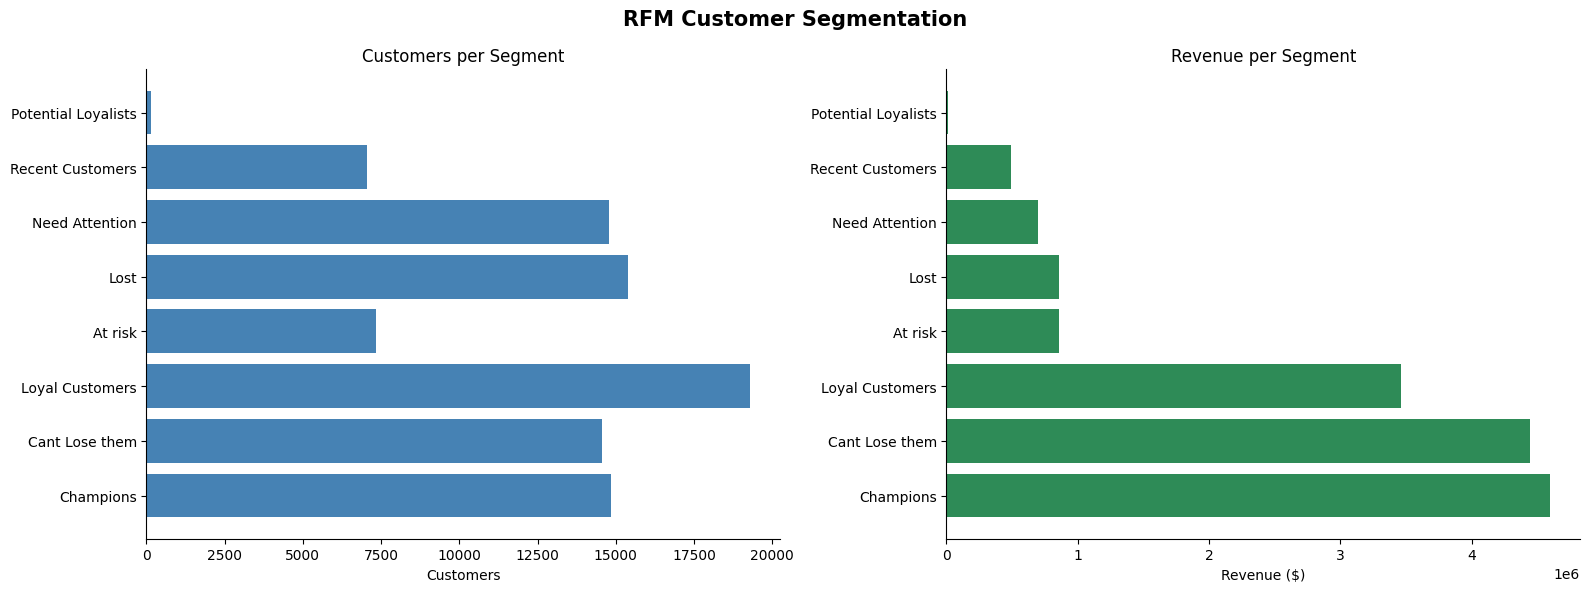

In [17]:
#RFM SEGMENTS
rfm_summary=(rfm.groupby('segment')
            .agg(customers=('customer_unique_id','count'),
                revenue=('monetary','sum'))
            .sort_values('revenue',ascending=False)
            .reset_index())
fig,(ax1,ax2)=plt.subplots(1,2, figsize=(16,6))
ax1.barh(rfm_summary['segment'],
        rfm_summary['customers'],
        color='steelblue')
ax1.set_title('Customers per Segment')
ax1.set_xlabel('Customers')

ax2.barh(rfm_summary['segment'],
        rfm_summary['revenue'],
        color='seagreen')
ax2.set_title('Revenue per Segment')
ax2.set_xlabel('Revenue ($)')

plt.suptitle('RFM Customer Segmentation',
            fontsize=15,fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segments.png')
plt.show()

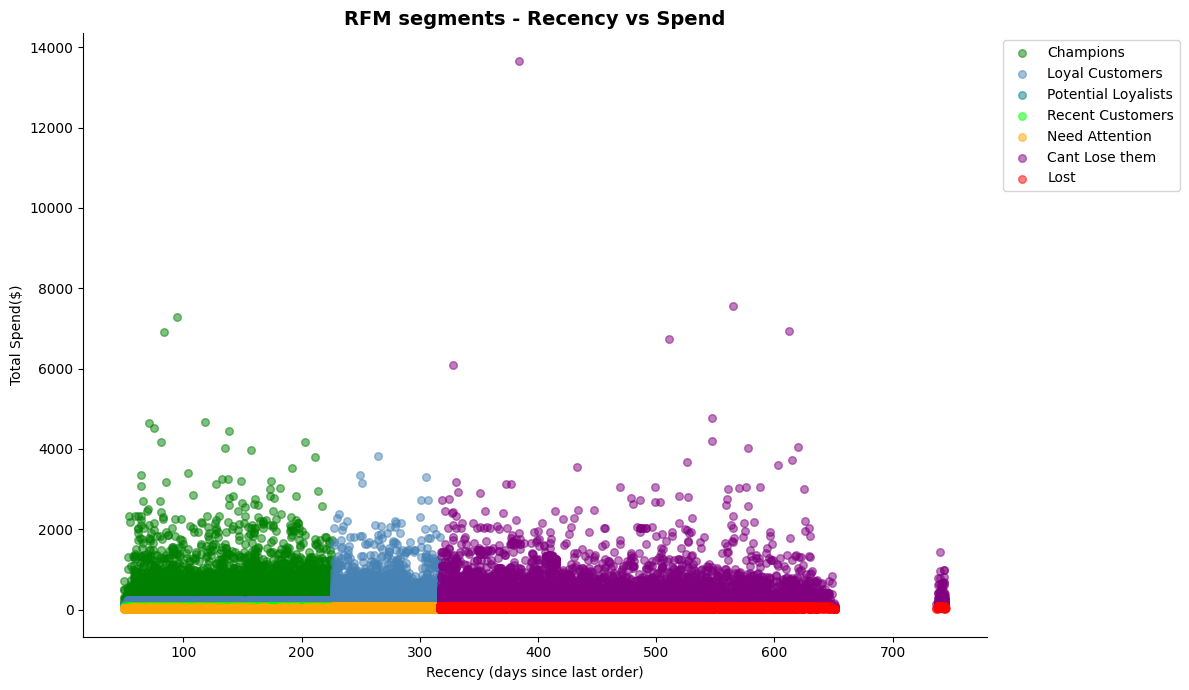

In [18]:
#RFM SCATTER PLOT
segment_colors={
    'Champions':'green',
    'Loyal Customers':'steelblue',
    'Potential Loyalists':'teal',
    'Recent Customers':'lime',
    'Need Attention':'orange',
    'At Risk':'tomato',
    'Cant Lose them':'purple',
    'Lost':'red'
}
plt.figure(figsize=(12,7))
for segment, color in segment_colors.items():
    mask=rfm['segment']==segment
    if mask.sum()==0:
        continue
    plt.scatter(rfm[mask]['recency'],
               rfm[mask]['monetary'],
               c=color,label=segment,
               alpha=0.5,s=30)
plt.xlabel('Recency (days since last order)')
plt.ylabel('Total Spend($)')
plt.title('RFM segments - Recency vs Spend',
         fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01,1),loc='upper left')
plt.tight_layout()
plt.savefig('rfm_scatter.png')
plt.show()


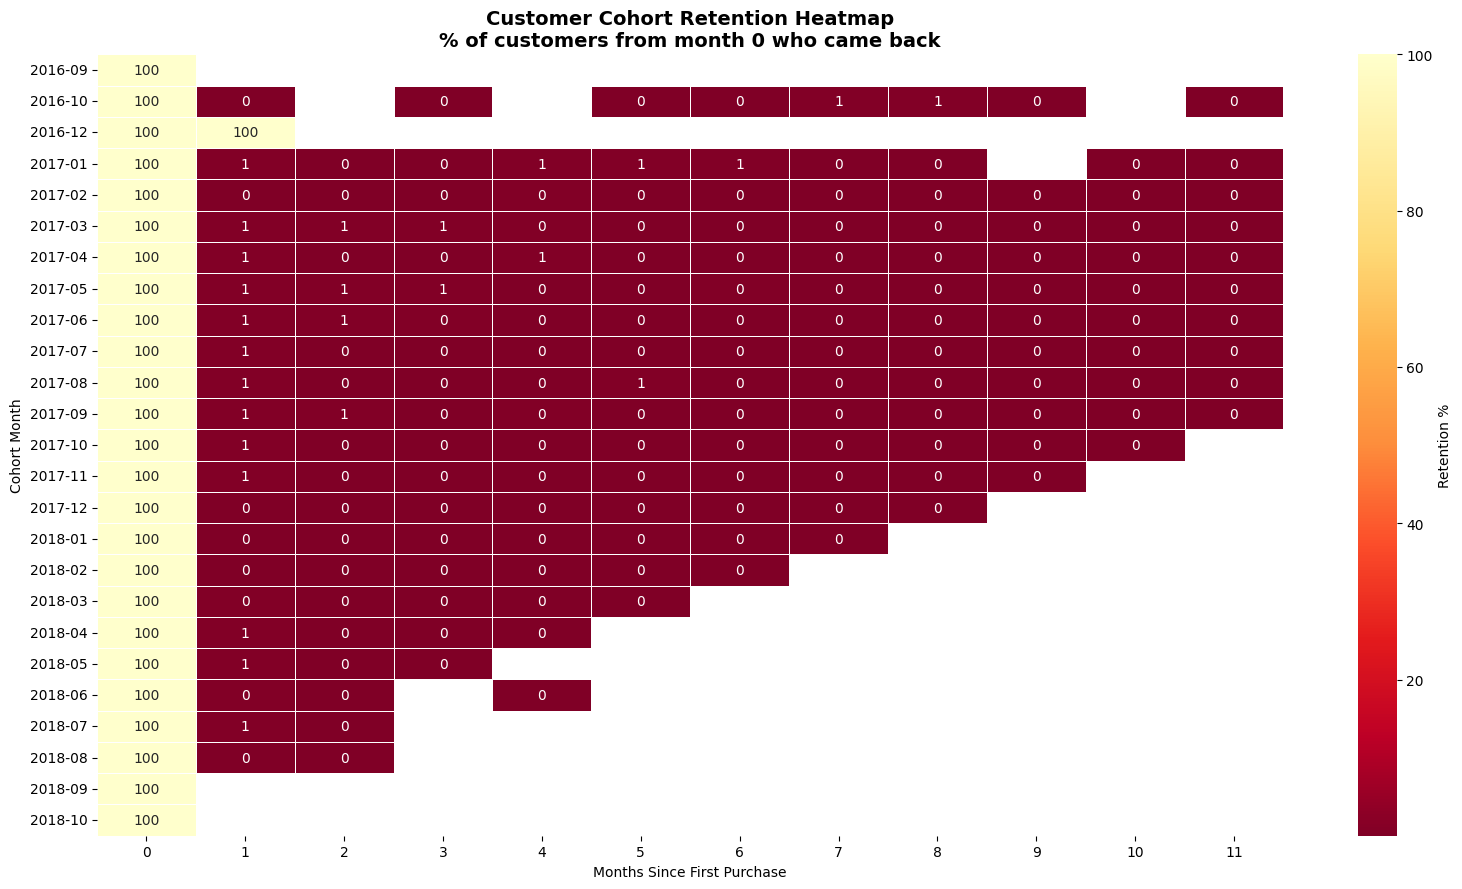

In [19]:
#COHORT RETENTION HEATMAP
cohort_pivot=cohort.pivot(
    index='cohort',
    columns='month_number',
    values='customers'
)

#convert to retention percentage vs month 0
cohort_pct=cohort_pivot.divide(cohort_pivot[0],axis=0)*100

plt.figure(figsize=(16,9))
sns.heatmap(cohort_pct,
           annot=True, fmt='.0f',
           cmap='YlOrRd_r',
           linewidths=0.5,
           linecolor='white',
           cbar_kws={'label':'Retention %'})
plt.title('Customer Cohort Retention Heatmap\n'
         '% of customers from month 0 who came back',
         fontsize=14,fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_heatmap.png')
plt.show()

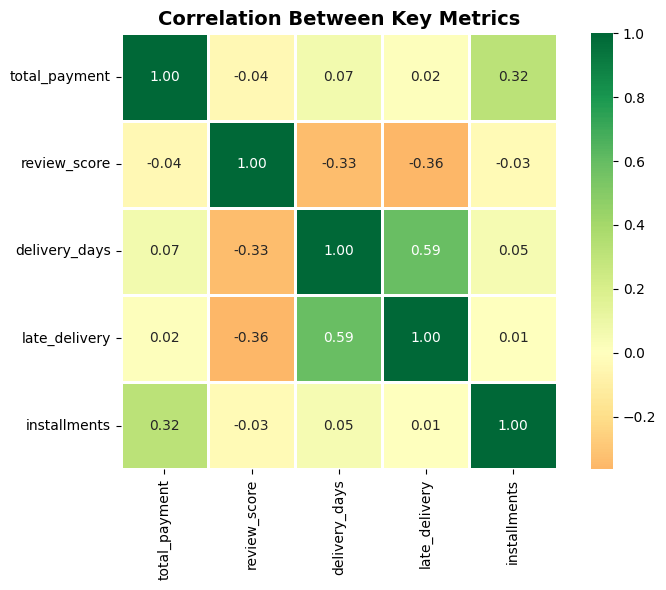

In [20]:
#CORRELATION HEATMAP
cols=['total_payment','review_score',
      'delivery_days','late_delivery','installments']
corr_data=order_master[cols].dropna()
plt.figure(figsize=(8,6))
sns.heatmap(corr_data.corr(),
           annot=True, fmt='.2f',
           cmap='RdYlGn',center=0,
           linewidths=1,square=True)
plt.title('Correlation Between Key Metrics',
         fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png')
plt.show()


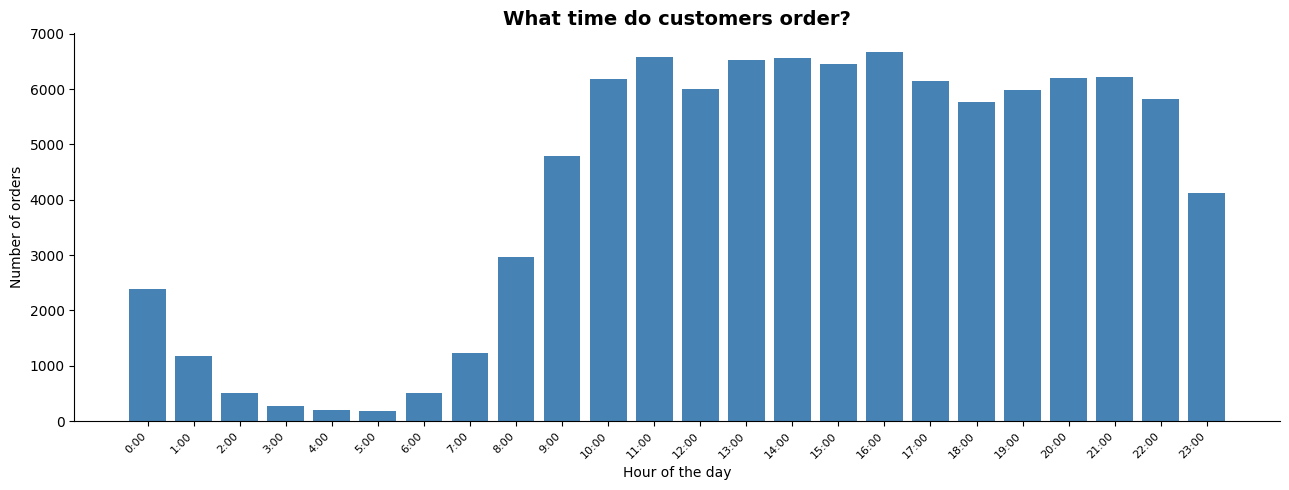

In [21]:
#HOURLY ORDER PATTERn
order_master['hour']=order_master['order_purchase_time'].dt.hour
hourly=order_master.groupby('hour').size().reset_index(name='orders')
plt.figure(figsize=(13,5))
plt.bar(hourly['hour'],hourly['orders'],color='steelblue')
plt.xticks(range(24),[f'{h}:00' for h in range(24)],
          rotation=45, ha='right', fontsize=8)
plt.title('What time do customers order?',
          fontsize=14,fontweight='bold')
plt.xlabel('Hour of the day')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.savefig('hourly_orders.png')
plt.show()

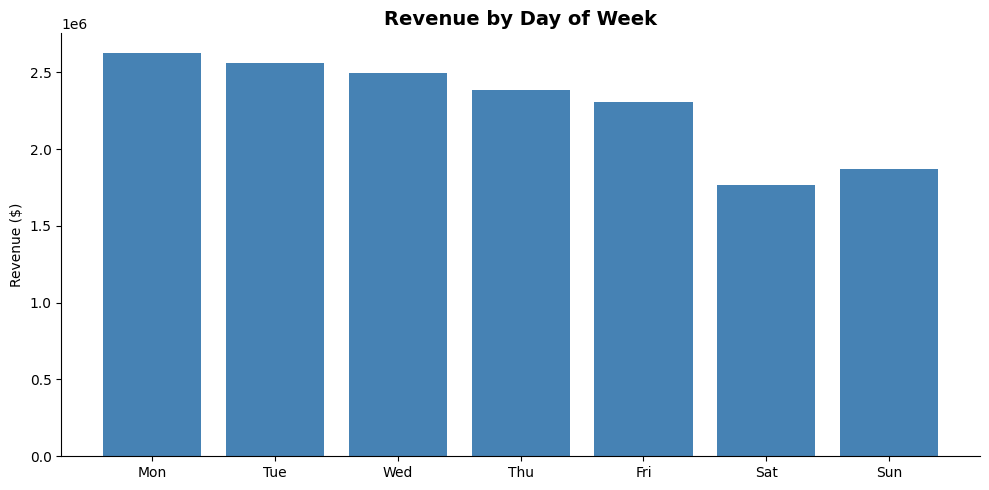

In [22]:
#DAY OF WEEK PATTERN
order_master['dow']=order_master['order_purchase_time'].dt.dayofweek
dow_names=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow=order_master.groupby('dow')['total_payment'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.bar([dow_names[d] for d in dow['dow']],
       dow['total_payment'],
       color='steelblue')
plt.title('Revenue by Day of Week',
         fontsize=14, fontweight='bold')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('day_of_week.png')
plt.show()


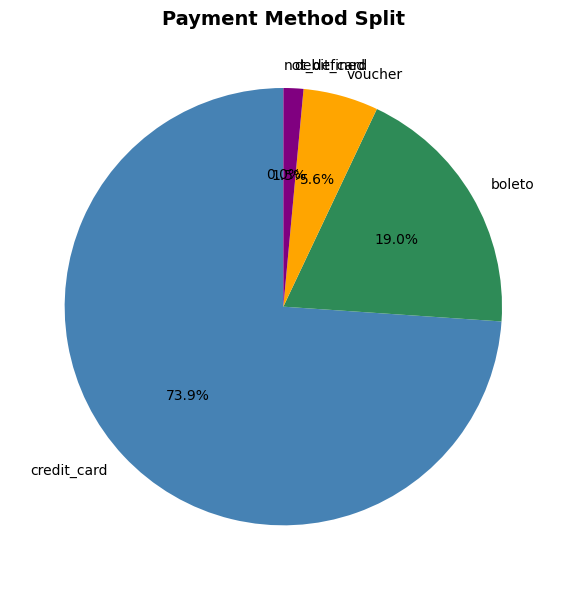

          type  count
0  credit_card  76795
1       boleto  19784
2      voucher   5775
3   debit_card   1529
4  not_defined      3


In [23]:
pay = (payment['payment_type']
       .value_counts()
       .reset_index())
pay.columns = ['type', 'count']

# Plot
plt.figure(figsize=(8, 6))
plt.pie(pay['count'],
        labels=pay['type'],
        autopct='%1.1f%%',
        colors=['steelblue', 'seagreen', 'orange', 'purple'],
        startangle=90)
plt.title('Payment Method Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('payment_types.png')
plt.show()

print(pay)